# PE-AV and CCA representational dissimilarity matrices

This notebook creates matched 5-s RDMs for PE-AV CLS-AV and the PE-AV top-1% CCA-A/CCA-P ROIs. Brain RDMs are made from multivertex ROI patterns (not scalar ROI means).

## Context & methods

The raw group-average source matches the standard RSA input. It receives only the main-analysis temporal alignment (5-s bins, 5-s delay, 5-s stride) and a within-run z-score. No HRF convolution, residualization, smoothing, or additional transform is applied here. CCA masks are PE-AV's own top-1% masks. RDM distance is correlation distance (1 − Pearson r).

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform

REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'rsa').is_dir())
MOVIE_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
from cf_modeling.roi_mean_partial_connectivity import _load_mask
from rsa.shared.rsa_utils import get_run_bin_counts, preprocess_fmri, process_model_embeddings

DATA = MOVIE_ROOT / 'data'
OUTPUTS = MOVIE_ROOT / 'outputs'
TIMING_CSV = DATA / 'movie_timing.csv'
MASKS = {
    'CCA-A_peav': OUTPUTS / 'cf_modeling/masks/cca_a_peav_1pct_mask.dscalar.nii',
    'CCA-P_peav': OUTPUTS / 'cf_modeling/masks/cca_p_peav_1pct_mask.dscalar.nii',
    'CCA-A_nemotron_l18': OUTPUTS / 'cf_modeling/masks/cca_a_nemotron_layer_18_mp_1pct_mask.dscalar.nii',
    'CCA-P_nemotron_l18': OUTPUTS / 'cf_modeling/masks/cca_p_nemotron_layer_18_mp_1pct_mask.dscalar.nii',
}
DTSERIES = DATA / 'preprocessed/average_sub/raw/group_average_raw_cortex_59k.dtseries.nii'
RUN_TRS_PATH = DATA / 'preprocessed/average_sub/raw/group_average_raw_run_trs.npy'
MODEL_EMBEDDINGS = {
    'PEAV_CLS-AV': OUTPUTS / 'model_embeddings/pe-av-small-16-frame/bin5s_skip5s/pe-av-small-16-frame_av.npy',
    'NEMOTRON_L18_AV': OUTPUTS / 'model_embeddings/nemotron_layer18_mp/bin5s_skip5s/nemotron_layer18_mp_av.npy',
}
ARTIFACT_DIR = REPO_ROOT / 'notebooks/visualization/rdm_outputs/peav_cca_5s_run_normalized'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
BIN_SEC = SKIP_SEC = DELAY_SEC = TR = 5.0
# The source data have 1-s TR; keep this separate from the 5-s window parameters.
TR = 1.0
timing = pd.read_csv(TIMING_CSV)
assert DTSERIES.exists() and RUN_TRS_PATH.exists()
assert all(path.exists() for path in MODEL_EMBEDDINGS.values()) and all(path.exists() for path in MASKS.values())


In [2]:
def stream_mask_patterns(dataobj, masks, n_trs, n_gray, batch_size=4096):
    """Read only the requested CIFTI columns, robustly across ArrayProxy backends."""
    counts = {name: int(mask.sum()) for name, mask in masks.items()}
    if any(count == 0 for count in counts.values()):
        raise ValueError(f'Empty mask(s): {counts}')
    result = {name: np.empty((n_trs, count), dtype=np.float32) for name, count in counts.items()}
    positions = {name: 0 for name in masks}
    for start in range(0, n_gray, batch_size):
        stop = min(start + batch_size, n_gray)
        active = {name: mask[start:stop] for name, mask in masks.items() if mask[start:stop].any()}
        if not active:
            continue
        block = np.asarray(dataobj[:, start:stop], dtype=np.float32)
        for name, local_mask in active.items():
            width = int(local_mask.sum())
            pos = positions[name]
            result[name][:, pos:pos + width] = block[:, local_mask]
            positions[name] += width
    assert all(positions[name] == counts[name] for name in masks)
    return result

def correlation_rdm(patterns):
    rdm = squareform(pdist(np.asarray(patterns, dtype=np.float64), metric='correlation'))
    np.fill_diagonal(rdm, 0.0)
    if not np.isfinite(rdm).all():
        raise ValueError('Non-finite correlation distances')
    return rdm.astype(np.float32)

def make_brain_rdms():
    image = nib.load(DTSERIES)
    n_trs, n_gray = image.shape
    run_trs = np.asarray(np.load(RUN_TRS_PATH), dtype=int)
    assert run_trs.sum() == n_trs
    masks = {name: _load_mask(path, n_gray) for name, path in MASKS.items()}
    patterns = stream_mask_patterns(image.dataobj, masks, n_trs, n_gray)
    rdms = {}
    for roi, values in patterns.items():
        binned = preprocess_fmri(values.T, timing, run_trs, BIN_SEC, TR, DELAY_SEC, skip_sec=SKIP_SEC, normalize=True)
        rdms[roi] = correlation_rdm(binned)
    return rdms, {roi: int(mask.sum()) for roi, mask in masks.items()}, run_trs

def save_rdm_plot(name, rdm, vmax):
    fig, ax = plt.subplots(figsize=(7.1, 6.1), dpi=180)
    image = ax.imshow(rdm, cmap='coolwarm', vmin=0.0, vmax=vmax, interpolation='nearest', aspect='equal')
    ax.set(title=name.replace('_', ' '), xlabel='5-s segment', ylabel='5-s segment')
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label('Correlation distance (1 − Pearson r)')
    fig.tight_layout()
    path = ARTIFACT_DIR / f'{name}.png'
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)
    return path


## Data and RDM construction

In [3]:
brain_rdms, vertex_counts, model_run_trs = make_brain_rdms()

# The intact audiovisual CLS-AV representations, matched to the same binning and per-run z-score.
rdms = dict(brain_rdms)
for name, path in MODEL_EMBEDDINGS.items():
    patterns = process_model_embeddings(str(path), timing, BIN_SEC, TR, model_run_trs, delay_sec=DELAY_SEC, hrf=False, skip_sec=SKIP_SEC, model_norm='zscore')
    rdms[name] = correlation_rdm(patterns)
run_bins = get_run_bin_counts(timing, model_run_trs, BIN_SEC, TR, DELAY_SEC, SKIP_SEC)
assert run_bins.tolist() == [151, 161, 156, 158]
assert all(rdm.shape == (int(run_bins.sum()), int(run_bins.sum())) for rdm in rdms.values())
for name, rdm in rdms.items():
    np.save(ARTIFACT_DIR / f'{name}.npy', rdm)

summary = pd.DataFrame([{
    'RDM': name, 'segments': rdm.shape[0], 'off_diagonal_min': float(rdm[np.triu_indices_from(rdm, 1)].min()),
    'off_diagonal_max': float(rdm[np.triu_indices_from(rdm, 1)].max()),
    'off_diagonal_mean': float(rdm[np.triu_indices_from(rdm, 1)].mean()),
} for name, rdm in rdms.items()]).set_index('RDM')
summary


,segments,off_diagonal_min,off_diagonal_max,off_diagonal_mean
RDM,,,,
CCA-A_peav,626,0.044288,1.937823,1.000565
CCA-P_peav,626,0.015971,1.981297,1.001359
CCA-A_nemotron_l18,626,0.050836,1.931774,1.000821
CCA-P_nemotron_l18,626,0.014440,1.981265,1.001403
PEAV_CLS-AV,626,0.051230,1.446118,1.001276
NEMOTRON_L18_AV,626,0.052806,1.469978,1.001258


## Results

All panels below use the same blue-to-red palette and the same 0-to-global-maximum color scale.

In [4]:
shared_vmax = max(float(rdm[np.triu_indices_from(rdm, 1)].max()) for rdm in rdms.values())
metadata = {
    'segment_definition': '5-s windows, 5-s stride, 5-s fMRI delay; 626 aligned bins',
    'normalization': 'within-run z-score only after binning',
    'other_processing': 'none in this notebook (no HRF convolution, residualization, smoothing, or additional transform)',
    'rdm_metric': 'correlation distance (1 - Pearson r)',
    'color_map': 'coolwarm (blue to red)', 'color_scale': [0.0, shared_vmax],
    'run_bins': run_bins.tolist(), 'roi_vertex_counts': vertex_counts,
    'source': {'dtseries': str(DTSERIES), 'run_trs': str(RUN_TRS_PATH)},
    'model_sources': {name: str(path) for name, path in MODEL_EMBEDDINGS.items()},
    'files': {name: {'rdm': f'{name}.npy'} for name in rdms},
}
(ARTIFACT_DIR / 'metadata.json').write_text(json.dumps(metadata, indent=2) + '\n')
print(f'Saved {len(rdms)} RDMs, matched color scale 0–{shared_vmax:.4f}, to {ARTIFACT_DIR}')
summary


Saved 6 RDMs, matched color scale 0–1.9813, to /home/amin/Research/Representation/Movie/movie_watching/notebooks/visualization/rdm_outputs/peav_cca_5s_run_normalized


,segments,off_diagonal_min,off_diagonal_max,off_diagonal_mean
RDM,,,,
CCA-A_peav,626,0.044288,1.937823,1.000565
CCA-P_peav,626,0.015971,1.981297,1.001359
CCA-A_nemotron_l18,626,0.050836,1.931774,1.000821
CCA-P_nemotron_l18,626,0.014440,1.981265,1.001403
PEAV_CLS-AV,626,0.051230,1.446118,1.001276
NEMOTRON_L18_AV,626,0.052806,1.469978,1.001258


In [ ]:
def zscore_rdm(rdm):
    """Standardize by the off-diagonal mean and standard deviation, so RDMs with different spreads are comparable."""
    upper = rdm[np.triu_indices_from(rdm, 1)]
    return (rdm - upper.mean()) / upper.std()

reference = 'PEAV_CLS-AV'
# Raw distances differ ~3-4x in spread (brain sd ~0.4-0.5, model sd ~0.13), so the difference is taken on z-scored RDMs.
diff_rdms = {name: zscore_rdm(rdm) - zscore_rdm(rdms[reference]) for name, rdm in rdms.items() if name != reference}
for rdm in diff_rdms.values():
    np.fill_diagonal(rdm, 0.0)
diff_vmax = max(np.percentile(np.abs(rdm), 99.5) for rdm in diff_rdms.values())

rdm_rows = [
    ('CCA-A_peav', 'CCA-P_peav', 'PEAV_CLS-AV'),
    ('CCA-A_nemotron_l18', 'CCA-P_nemotron_l18', 'NEMOTRON_L18_AV'),
]
fig, axes = plt.subplots(2, 3, figsize=(18, 13), dpi=140, gridspec_kw={"hspace": 0.25})
diff_axes = []
for ax, name in zip(axes.ravel(), (name for row in rdm_rows for name in row)):
    if name == reference:  # reference panel: the raw RDM that was subtracted from the others
        ref_im = ax.imshow(rdms[name], cmap='coolwarm', vmin=0.0, vmax=shared_vmax, interpolation='nearest', aspect='equal')
        ax.set(title=f'{name.replace("_", " ")} (reference, raw)', xlabel='5-s segment', ylabel='5-s segment')
        fig.colorbar(ref_im, ax=ax, fraction=0.046, pad=0.04, label='Correlation distance (1 − Pearson r)')
        continue
    im = ax.imshow(diff_rdms[name], cmap='coolwarm', vmin=-diff_vmax, vmax=diff_vmax, interpolation='nearest', aspect='equal')
    ax.set(title=f'{name.replace("_", " ")} − PEAV CLS-AV', xlabel='5-s segment', ylabel='5-s segment')
    diff_axes.append(ax)
fig.colorbar(im, ax=diff_axes, location='bottom', fraction=0.04, pad=0.08, shrink=0.6, label='Difference in z-scored distance (red: farther apart than in PEAV CLS-AV)')
plt.show()

In [6]:
names = list(rdms.keys())
vecs = {name: rdms[name][np.triu_indices_from(rdms[name], 1)] for name in names}
corr_table = pd.DataFrame(
    [[np.corrcoef(vecs[a], vecs[b])[0, 1] for b in names] for a in names],
    index=names, columns=names,
)
corr_table.to_csv(ARTIFACT_DIR / 'rdm_correlations.csv')
corr_table


,CCA-A_peav,CCA-P_peav,CCA-A_nemotron_l18,CCA-P_nemotron_l18,PEAV_CLS-AV,NEMOTRON_L18_AV
CCA-A_peav,1.000000,0.374058,0.977013,0.320313,0.187831,0.304021
CCA-P_peav,0.374058,1.000000,0.342743,0.964916,0.161460,0.225092
CCA-A_nemotron_l18,0.977013,0.342743,1.000000,0.290429,0.184909,0.297685
CCA-P_nemotron_l18,0.320313,0.964916,0.290429,1.000000,0.147862,0.206116
PEAV_CLS-AV,0.187831,0.161460,0.184909,0.147862,1.000000,0.619735
NEMOTRON_L18_AV,0.304021,0.225092,0.297685,0.206116,0.619735,1.000000


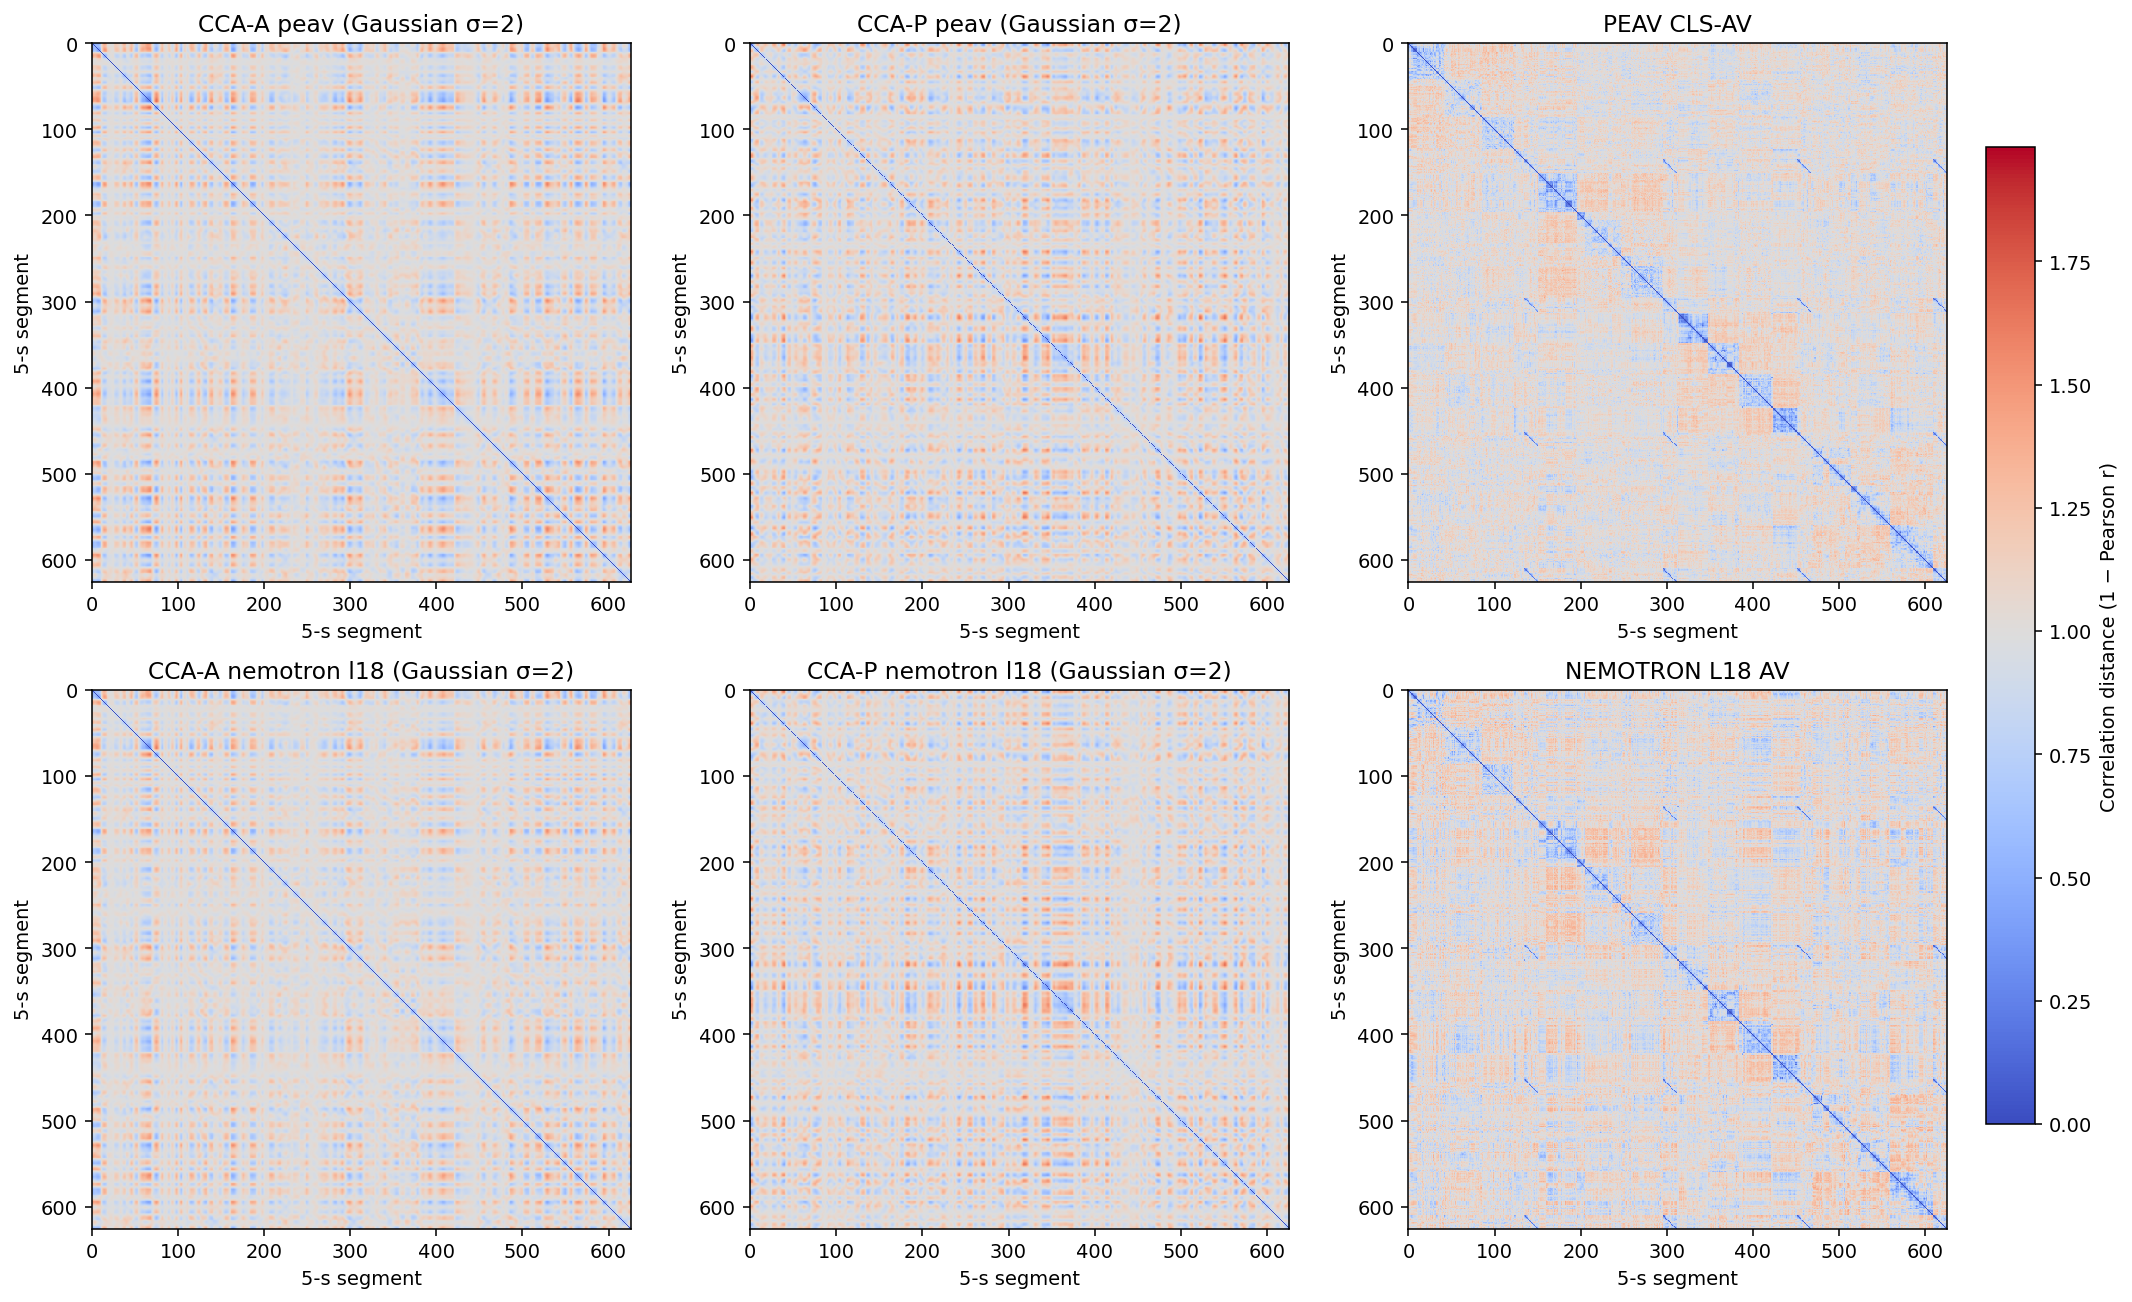

AttributeError: module 'matplotlib.pyplot' has no attribute 'save'

In [ ]:
from scipy.ndimage import gaussian_filter

smoothing_sigma = 2
display_rdms = {name: gaussian_filter(rdm, sigma=smoothing_sigma, mode='nearest') if name.startswith('CCA-') else rdm for name, rdm in rdms.items()}
for name, rdm in display_rdms.items():
    if name.startswith('CCA-'):
        np.fill_diagonal(rdm, 0.0)
fig, axes = plt.subplots(2, 3, figsize=(18, 11), dpi=140)
for ax, name in zip(axes.ravel(), (name for row in rdm_rows for name in row)):
    rdm = display_rdms[name]
    image = ax.imshow(rdm, cmap='coolwarm', vmin=0.0, vmax=shared_vmax, interpolation='nearest', aspect='equal')
    suffix = f' (Gaussian σ={smoothing_sigma:g})' if name.startswith('CCA-') else ''
    ax.set(title=name.replace('_', ' ') + suffix, xlabel='5-s segment', ylabel='5-s segment')
fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02, label='Correlation distance (1 − Pearson r)')
plt.show()



In [ ]:
# (1) Distance versus temporal lag within a run: how quickly neighbouring 5-s segments become dissimilar.
run_id = np.repeat(np.arange(len(run_bins)), run_bins)
lags = np.arange(1, 41)
fig, ax = plt.subplots(figsize=(8, 5), dpi=140)
for name, rdm in rdms.items():
    z = zscore_rdm(rdm)
    profile = [np.mean([z[i, i + lag] for i in range(len(z) - lag) if run_id[i] == run_id[i + lag]]) for lag in lags]
    ax.plot(lags * BIN_SEC, profile, label=name.replace('_', ' '))
ax.set(xlabel='Temporal lag between segments (s)', ylabel='Mean z-scored distance (within run)', title='RDM distance versus temporal lag')
ax.legend(fontsize=8)
plt.show()

# (2) Cross-RDM scatter density: does a pair of segments that is far apart in PEAV CLS-AV also look far apart in the brain?
fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi=140, sharex=True, sharey=True)
ref_vec = vecs[reference]
for ax, name in zip(axes, [n for n in rdms if n != reference and n != 'NEMOTRON_L18_AV']):
    ax.hexbin(ref_vec, vecs[name], gridsize=60, bins='log', cmap='viridis')
    ax.set(xlabel='PEAV CLS-AV distance', title=f'{name.replace("_", " ")}  (r = {corr_table.loc[name, reference]:.2f})')
axes[0].set_ylabel('Brain-ROI RDM distance')
plt.show()